# 03 · Extra: hypervolume, early stopping & model selection

Optional extras for when the basics are in place: what the early-stopping indicator
measures, how early stopping is switched on, and how GPU plugs into scikit-learn
cross-validation, grid search and pipelines.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from foresight_gpu import GPURegressor
from foresight_gpu.models import MLPModel
from foresight_gpu.scoring import make_gpu_scorer
from foresight_gpu.utils import plot_hypervolume

rng = np.random.default_rng(0)
X = rng.uniform(-1, 1, size=(500, 2))
y = np.sin(2 * np.pi * X[:, 0]) + 0.3 * X[:, 1] + 0.25 * rng.standard_normal(500)

cut = 400                                   # chronological 80/20 split
X_tr, y_tr, X_va, y_va = X[:cut], y[:cut], X[cut:], y[cut:]
print('train', X_tr.shape, '| validation', X_va.shape)

train (400, 2) | validation (100, 2)


## 1 · The hypervolume indicator

GPU keeps a population of models, each with a non-exceedance level $\eta$ and a loss. Front 0
is the lowest loss reached at each $\eta$. The **hypervolume** is the area between that
staircase and a ceiling $P$, reported normalised as $hv = 1 - D/P \in [0, 1]$ (higher is
better), where $D$ integrates the loss over the covered $\eta$ range and charges $P$ for every
uncovered stretch. It therefore rises both when the loss drops and when the front spreads
across the exceedance axis. The default ceiling is $P = 100$.

Note that the lowest-loss particle (the anchor) sits below the staircase: its cell has zero
width, so `hv` measures the tails and shoulders of the front, not the single best model.

hv = 0.8759 | coverage = 0.99 | front size = 45


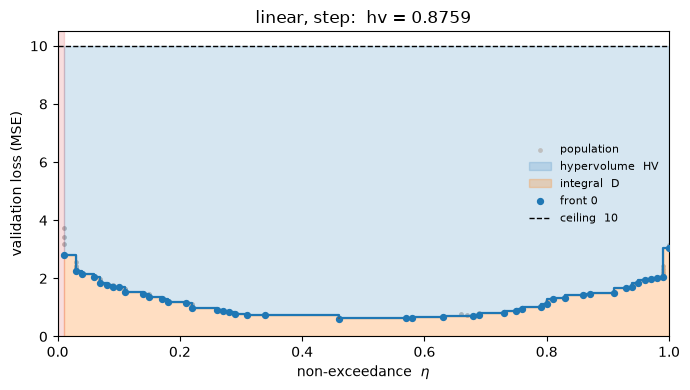

In [2]:
# hv_penalty=10 gives a tight ceiling so the shaded area is legible (default is 100).
demo = GPURegressor(population=100, metric='mse', n_iter=40,
                    hv_penalty=10, random_state=0).fit(X_tr, y_tr)
eta, loss, front = demo.ensemble_.front_objectives(X_va, y_va)

ax = plot_hypervolume(eta, loss, demo.hv_penalty_, front=front,
                      ylabel='validation loss (MSE)')
ax.figure.set_size_inches(7, 4)
ax.figure.tight_layout()

parts = demo.ensemble_.score_hypervolume(X_va, y_va, details=True)
print(f"hv = {parts['hv']:.4f} | coverage = {parts['coverage']:.2f} | front size = {parts['n_front']}")

## 2 · Early stopping

There is no `early_stopping` flag: it runs whenever validation data exists, monitoring the
validation hypervolume every `check_every` generations and restoring the best ensemble after
`n_iter_no_change` checks without improvement.

| call | early stopping |
|---|---|
| `fit(X, y)` | off — full `n_iter`, whole record trains |
| `GPURegressor(validation_fraction=0.2).fit(X, y)` | on, internal chronological tail |
| `fit(X, y, X_val=Xv, y_val=yv)` | on, your split; **all** of `X` trains |

early stopping ran: True
stopped at iteration 31 | best iteration 5


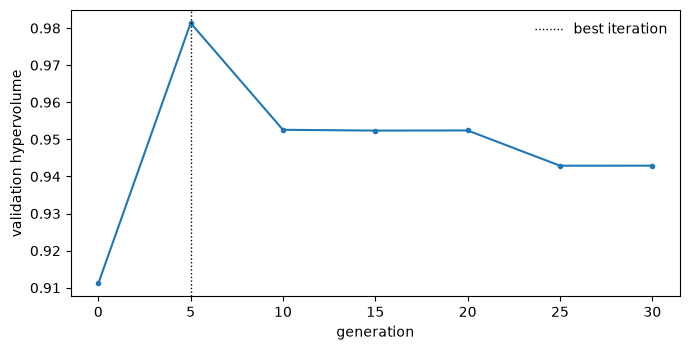

In [3]:
gpu_es = GPURegressor(population=300, n_iter=400, n_iter_no_change=5, check_every=5,
                      random_state=0).fit(X_tr, y_tr, X_val=X_va, y_val=y_va)
print('early stopping ran:', gpu_es.early_stopping_)
print('stopped at iteration', gpu_es.n_iter_, '| best iteration', gpu_es.best_iteration_)

it = [h['iteration'] for h in gpu_es.history_]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(it, [h['hv'] for h in gpu_es.history_], '-o', ms=3)
ax.axvline(gpu_es.best_iteration_, color='k', ls=':', lw=1, label='best iteration')
ax.set_xlabel('generation')
ax.set_ylabel('validation hypervolume')
ax.legend(frameon=False)
fig.tight_layout()

The same problem without validation data runs the full `n_iter`. Scoring both on the held-out
block shows what stopping bought (`score_hypervolume` reads the ensemble `predict` uses).

In [4]:
gpu_full = GPURegressor(population=300, n_iter=gpu_es.n_iter_ * 2,
                        random_state=0).fit(X_tr, y_tr)
print('early stopping ran:', gpu_full.early_stopping_, '| generations:', gpu_full.n_iter_)
print(f'with early stopping:    hv = {gpu_es.score_hypervolume(X_va, y_va):.4f}')
print(f'without early stopping: hv = {gpu_full.score_hypervolume(X_va, y_va):.4f}')

early stopping ran: False | generations: 62
with early stopping:    hv = 0.9814
without early stopping: hv = 0.9428


## 3 · Time-series cross-validation on a probabilistic score

`make_gpu_scorer` builds scorers that use the probabilistic output (the default sklearn
scorer only sees `predict`).

> Cross-validation does not slice `X_val`: passed through `fit`, every fold gets the same
> block. Inside CV use `validation_fraction` so each fold carves its own tail.

In [5]:
est = GPURegressor(population=200, n_iter=40, random_state=0)
for name in ('reliability', 'hypervolume'):
    scores = cross_val_score(est, X, y, cv=TimeSeriesSplit(4), scoring=make_gpu_scorer(name))
    print(f'{name:12s} per fold:', np.round(scores, 3))

reliability  per fold: [0.866 0.908 0.959 0.927]


hypervolume  per fold: [0.975 0.954 0.983 0.982]


## 4 · Grid search over model and regularisation parameters

The forward model is a nested parameter, so `model__*` is searchable.

In [6]:
search = GridSearchCV(
    GPURegressor(model=MLPModel(), population=150, n_iter=30, random_state=0),
    {'model__n_hidden': [4, 8], 'reg_lambda': [0.0, 1e-3]},
    cv=TimeSeriesSplit(3), scoring=make_gpu_scorer('hypervolume'))
search.fit(X, y)
print('best params:', search.best_params_)

best params: {'model__n_hidden': 4, 'reg_lambda': 0.0}


## 5 · Pipelines: the scaling is yours

`GPURegressor` normalises nothing. Scale `X` with a `Pipeline` step; `y` is out of a
pipeline's reach, so tell the MLP the target's range with `output_scale` / `output_offset`
(its bounded weights cannot reach a target far from zero otherwise, and `predict` would be
all-NaN).

In [7]:
X_big = X * np.array([40.0, 0.1]) + np.array([500.0, -3.0])
y_big = y * 50.0 + 2000.0

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    bare = GPURegressor(population=300, n_iter=40, random_state=0).fit(X_big, y_big)
print('bare estimator -> finite predictions:', f'{np.isfinite(bare.predict(X_big)).mean():.0%}')
for c in caught:
    print('   !', str(c.message)[:120], '...')

pipe = make_pipeline(
    StandardScaler(),                                   # X: the pipeline's job
    GPURegressor(                                       # y: the model's job
        model=MLPModel(output_scale=y_big.std(), output_offset=y_big.mean()),
        population=300, n_iter=40, random_state=0),
).fit(X_big, y_big)
print('pipeline       -> finite predictions:', f'{np.isfinite(pipe.predict(X_big)).mean():.0%}',
      f'| R2 = {pipe.score(X_big, y_big):.3f}')

bands = pipe[-1].predict_quantiles(pipe[0].transform(X_big))   # bands in data units

bare estimator -> finite predictions: 0%
   ! Every particle has exceedance 0: MLPModel never brackets y, so no band can be populated and predict() will be all-NaN. T ...


pipeline       -> finite predictions: 100% | R2 = 0.318


**Summary.** `metric` is the training loss that shapes the front; `scoring` is the held-out
criterion for early stopping and model selection. Tune the front with `metric`, select and
stop with `scoring`.

**Notebooks:** `00_quickstart` · `01_custom_model` · `02_gr4j` · `03_extra_diagnostics` ·
`04_uncertainty_experiments`